# t-SNE for Non-linear Dimensionality Reduction and Visualization

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand t-SNE fundamentals and its use in non-linear dimensionality reduction
- Implement t-SNE in Python for data visualization
- Analyze properties and effectiveness of t-SNE
- Compare t-SNE with PCA and SVD for high-dimensional data analysis
- Apply t-SNE on real-world datasets including images and text data

## 🔗 Prerequisites

- ✅ Unit 1: Linear Algebra
- ✅ Unit 4: PCA and SVD implementation
- ✅ Understanding of dimensionality reduction concepts

---

This notebook covers practical activities from **Course 03, Unit 4**:
- Using t-SNE for visualizing high-dimensional data in 2D or 3D dimensions
- Comparing PCA, SVD, and t-SNE for different data analysis tasks
- Writing code to apply dimensionality reduction techniques on real-world datasets

---

## Introduction

**t-SNE (t-distributed Stochastic Neighbor Embedding)** is a non-linear dimensionality reduction technique that preserves local neighborhood structures, making it excellent for visualization.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.decomposition import PCA

# Try importing t-SNE
try:
    from sklearn.manifold import TSNE
    HAS_TSNE = True
    print("✅ t-SNE available from sklearn.manifold")
except ImportError:
    HAS_TSNE = False
    print("⚠️  t-SNE not available. Install with: pip install scikit-learn")

print("✅ Libraries imported!")


✅ t-SNE available from sklearn.manifold
✅ Libraries imported!


## Part 1: Understanding t-SNE Fundamentals

t-SNE preserves local neighborhood structures in high-dimensional data.


In [2]:
print("=" * 60)
print("t-SNE Fundamentals")
print("=" * 60)

print("\nKey Characteristics:")
print("  1. Non-linear dimensionality reduction")
print("  2. Preserves local neighborhood structures")
print("  3. Excellent for visualization (2D/3D)")
print("  4. Computationally expensive for large datasets")
print("  5. Stochastic - results vary with different random seeds")

print("\n✅ t-SNE is ideal for:")
print("  - Visualizing high-dimensional data")
print("  - Understanding data clusters and structure")
print("  - Exploratory data analysis")


t-SNE Fundamentals

Key Characteristics:
  1. Non-linear dimensionality reduction
  2. Preserves local neighborhood structures
  3. Excellent for visualization (2D/3D)
  4. Computationally expensive for large datasets
  5. Stochastic - results vary with different random seeds

✅ t-SNE is ideal for:
  - Visualizing high-dimensional data
  - Understanding data clusters and structure
  - Exploratory data analysis


## Part 2: Implementing t-SNE for Visualization


t-SNE Implementation
Original data shape: (300, 50)
Number of classes: 5

Applying t-SNE (this may take a moment)...


t-SNE reduced shape: (300, 2)
✅ t-SNE transformation complete!


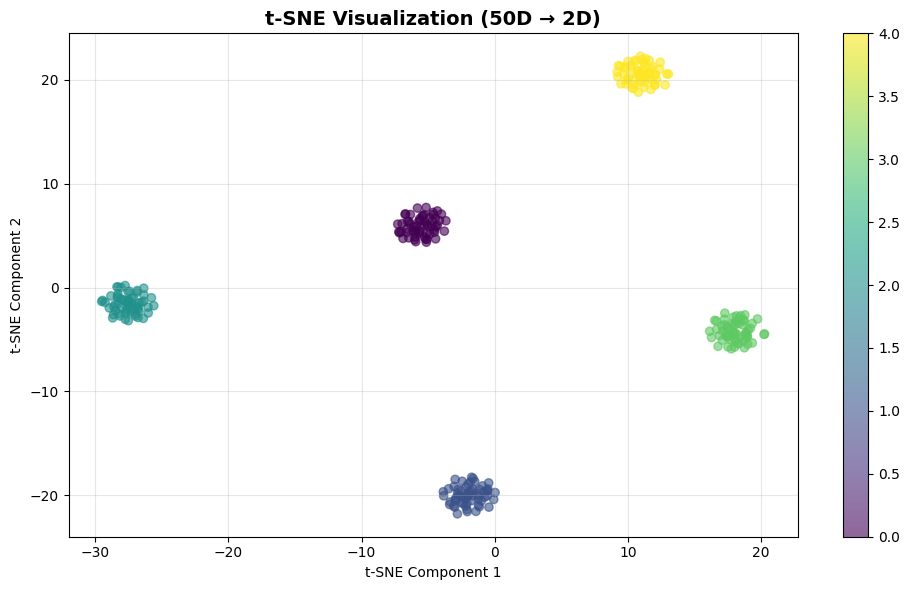


✅ t-SNE preserves local clusters in 2D visualization!


In [3]:
if HAS_TSNE:
    # Generate sample high-dimensional data
    X, y = make_blobs(n_samples=300, n_features=50, centers=5, random_state=42)
    
    print("=" * 60)
    print("t-SNE Implementation")
    print("=" * 60)
    print(f"Original data shape: {X.shape}")
    print(f"Number of classes: {len(np.unique(y))}")
    
    # Apply t-SNE
    print("\nApplying t-SNE (this may take a moment)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X)
    
    print(f"t-SNE reduced shape: {X_tsne.shape}")
    print("✅ t-SNE transformation complete!")
    
    # Visualize
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('t-SNE Visualization (50D → 2D)', fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n✅ t-SNE preserves local clusters in 2D visualization!")
else:
    print("=" * 60)
    print("t-SNE Implementation (Installation Required)")
    print("=" * 60)
    print("""
    To use t-SNE:
    
    1. Install scikit-learn:
       pip install scikit-learn
    
    2. Import and use:
       from sklearn.manifold import TSNE
       
       tsne = TSNE(n_components=2, random_state=42, perplexity=30)
       X_tsne = tsne.fit_transform(X)
    
    3. Parameters:
       - n_components: Output dimensions (2 or 3 for visualization)
       - perplexity: Balance between local and global structure (typically 30-50)
       - random_state: For reproducible results
    """)


## Part 3: Comparing PCA, SVD, and t-SNE


Comparing PCA, SVD, and t-SNE
Dataset: Iris (4 features, 3 classes)


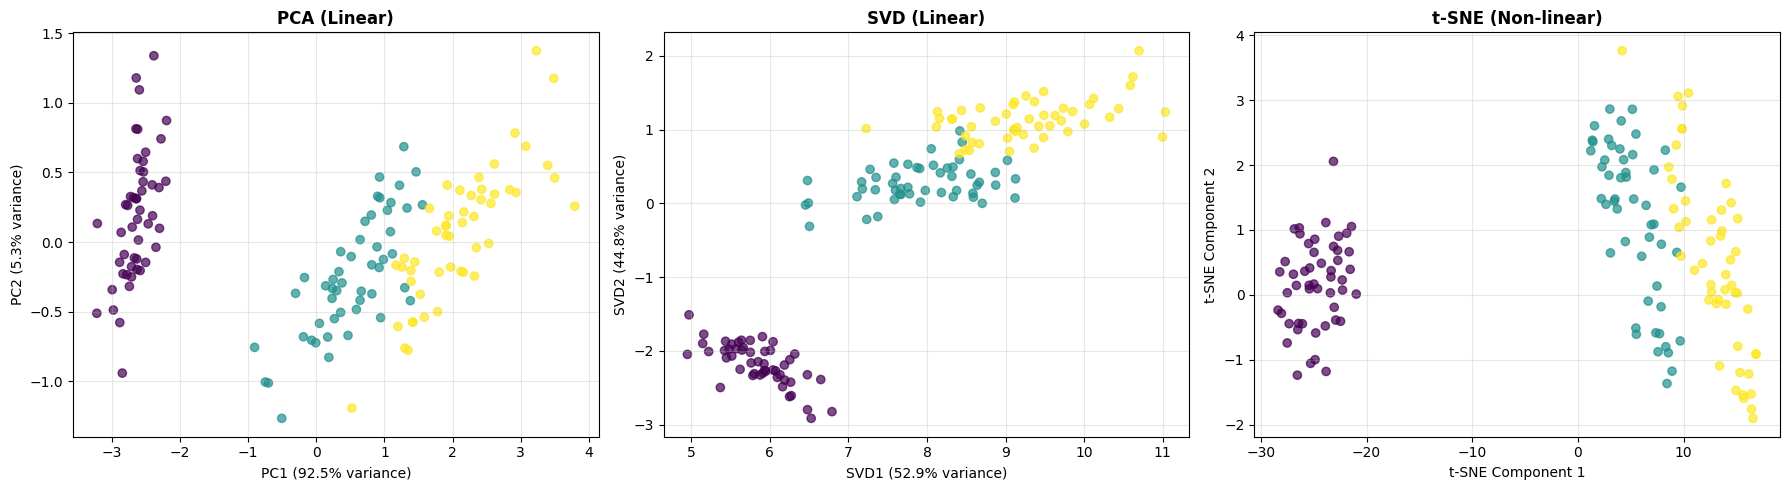


✅ Comparison Results:
  - PCA/SVD: Linear, preserves global structure, fast
  - t-SNE: Non-linear, preserves local neighborhoods, slower
  - Use PCA/SVD for dimensionality reduction and compression
  - Use t-SNE for visualization and exploratory analysis


In [4]:
if HAS_TSNE:
    # Load Iris dataset for comparison
    iris = load_iris()
    X_iris, y_iris = iris.data, iris.target
    
    print("=" * 60)
    print("Comparing PCA, SVD, and t-SNE")
    print("=" * 60)
    print(f"Dataset: Iris (4 features, 3 classes)")
    
    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_iris)
    
    # SVD (TruncatedSVD)
    from sklearn.decomposition import TruncatedSVD
    svd = TruncatedSVD(n_components=2)
    X_svd = svd.fit_transform(X_iris)
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_iris)
    
    # Visualize all three
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # PCA
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap='viridis', alpha=0.7)
    axes[0].set_title('PCA (Linear)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    axes[0].grid(True, alpha=0.3)
    
    # SVD
    axes[1].scatter(X_svd[:, 0], X_svd[:, 1], c=y_iris, cmap='viridis', alpha=0.7)
    axes[1].set_title('SVD (Linear)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(f'SVD1 ({svd.explained_variance_ratio_[0]:.1%} variance)')
    axes[1].set_ylabel(f'SVD2 ({svd.explained_variance_ratio_[1]:.1%} variance)')
    axes[1].grid(True, alpha=0.3)
    
    # t-SNE
    scatter = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_iris, cmap='viridis', alpha=0.7)
    axes[2].set_title('t-SNE (Non-linear)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('t-SNE Component 1')
    axes[2].set_ylabel('t-SNE Component 2')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Comparison Results:")
    print("  - PCA/SVD: Linear, preserves global structure, fast")
    print("  - t-SNE: Non-linear, preserves local neighborhoods, slower")
    print("  - Use PCA/SVD for dimensionality reduction and compression")
    print("  - Use t-SNE for visualization and exploratory analysis")
else:
    print("Note: Install scikit-learn to compare PCA, SVD, and t-SNE")


## Summary

### Key Concepts:
1. **t-SNE**: t-distributed Stochastic Neighbor Embedding
   - Non-linear dimensionality reduction
   - Preserves local neighborhood structures
   - Excellent for visualization (2D/3D)

2. **Comparison**:
   - **PCA/SVD**: Linear, fast, preserves global structure, good for compression
   - **t-SNE**: Non-linear, slower, preserves local structure, excellent for visualization

3. **When to Use**:
   - **PCA/SVD**: Dimensionality reduction, compression, preprocessing
   - **t-SNE**: Visualization, exploratory analysis, understanding data structure

### Best Practices:
- Use PCA/SVD for initial dimensionality reduction
- Use t-SNE for visualization (typically on < 10,000 samples)
- Adjust perplexity parameter (typically 30-50) based on dataset size
- Results vary with random_state - run multiple times for stability

**Reference:** Course 03, Unit 4: "Dimensionality Reduction and Data Representation Techniques" - t-SNE practical content
